In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/lung-cancer-risk-dataset/lung_cancer_dataset.csv')

In [3]:
df.head(5)

,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,100000,69,Male,66.025244,High,No,No,Yes,Moderate,No,No
1,100001,32,Female,12.780800,High,No,Yes,Yes,Moderate,Yes,Yes
2,100002,89,Female,0.408278,Medium,Yes,Yes,Yes,NaN,No,Yes
3,100003,78,Female,44.065232,Low,No,Yes,No,Moderate,No,Yes
4,100004,38,Female,44.432440,Medium,Yes,No,Yes,NaN,Yes,Yes


In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
patient_id,50000.0,124999.500000,14433.901067,100000.000000,112499.750000,124999.500000,137499.25000,149999.000000
age,50000.0,58.857040,23.958266,18.000000,38.000000,59.000000,80.00000,100.000000
pack_years,50000.0,49.963424,28.852082,0.002753,24.774558,50.177634,75.06674,99.999204



Missing values per column:
patient_id                       0
age                              0
gender                           0
pack_years                       0
radon_exposure                   0
asbestos_exposure                0
secondhand_smoke_exposure        0
copd_diagnosis                   0
alcohol_consumption          16662
family_history                   0
lung_cancer                      0
dtype: int64


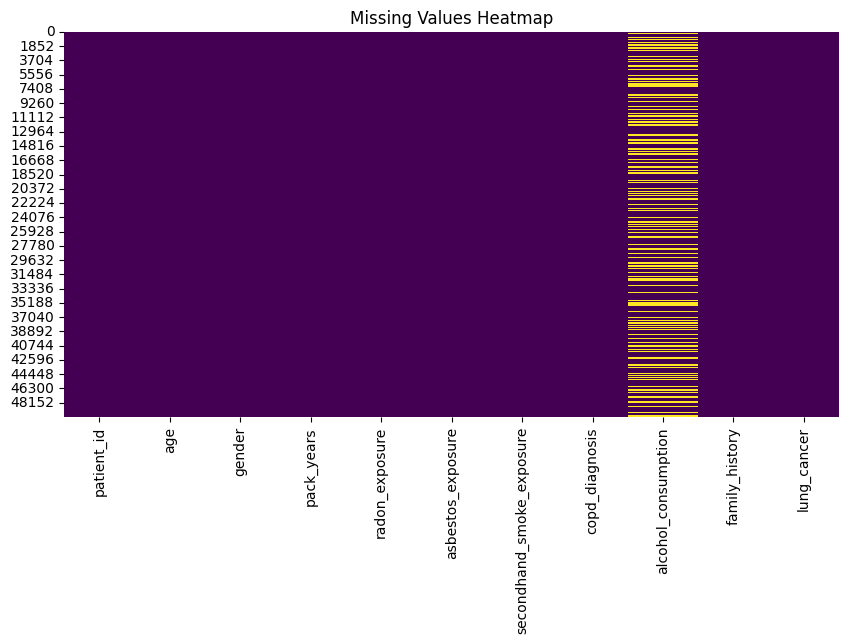

In [5]:
# ======================
#  MISSING VALUES
# ======================
print("\nMissing values per column:")
print(df.isnull().sum())

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [6]:
# finding unique, missing %, sample unique values
for col in df.columns:
    unique_vals = df[col].unique()
    n_unique = df[col].nunique()
    missing_pct = df[col].isna().mean() * 100
    
    print(f"Column: {col}")
    print(f"  Missing %: {missing_pct:.2f}%")
    print(f"  Unique Count: {n_unique}")
    
    # Show first few unique values (to avoid huge output)
    print(f"  Sample Unique Values: {unique_vals[:10]}")
    print("-"*40)


Column: patient_id
  Missing %: 0.00%
  Unique Count: 50000
  Sample Unique Values: [100000 100001 100002 100003 100004 100005 100006 100007 100008 100009]
----------------------------------------
Column: age
  Missing %: 0.00%
  Unique Count: 83
  Sample Unique Values: [ 69  32  89  78  38 100  92  41  20  39]
----------------------------------------
Column: gender
  Missing %: 0.00%
  Unique Count: 2
  Sample Unique Values: ['Male' 'Female']
----------------------------------------
Column: pack_years
  Missing %: 0.00%
  Unique Count: 50000
  Sample Unique Values: [66.02524418 12.78080002  0.4082781  44.06523181 44.43244048 81.18054512
 18.15675164 27.51111631  7.82423317 39.98750353]
----------------------------------------
Column: radon_exposure
  Missing %: 0.00%
  Unique Count: 3
  Sample Unique Values: ['High' 'Medium' 'Low']
----------------------------------------
Column: asbestos_exposure
  Missing %: 0.00%
  Unique Count: 2
  Sample Unique Values: ['No' 'Yes']
--------------

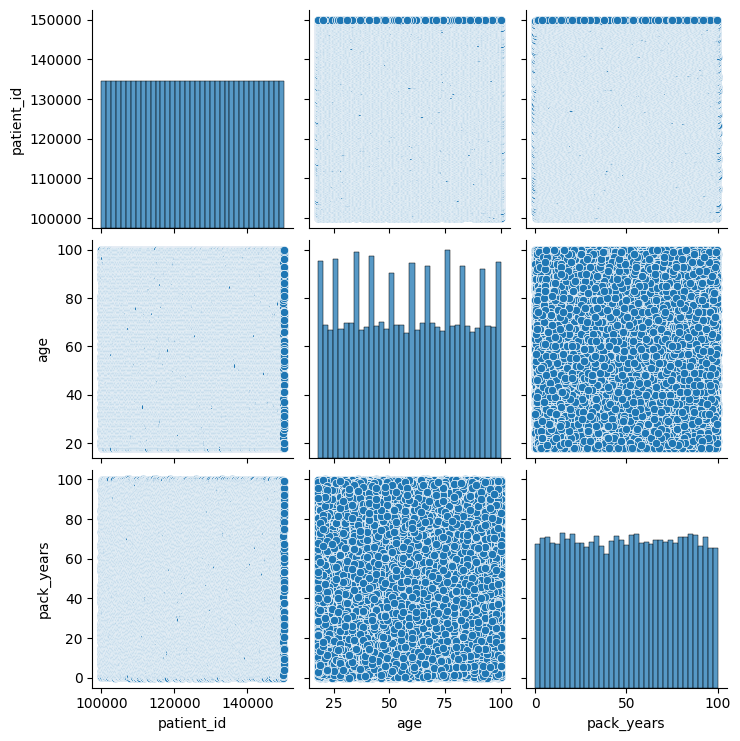

In [7]:
import warnings
warnings.filterwarnings("ignore")
sns.pairplot(df);

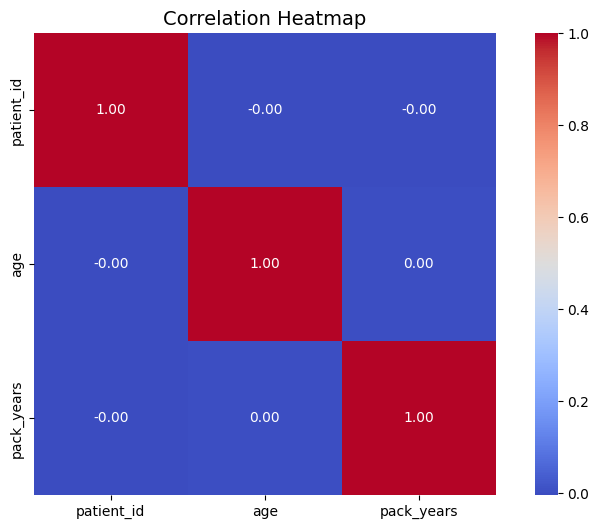

In [8]:
corr = df.corr(numeric_only=True)
# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

In [9]:
corr_sorted = corr.abs().unstack().sort_values(ascending=False)
print(corr_sorted.head(10))

patient_id  patient_id    1.000000
age         age           1.000000
pack_years  pack_years    1.000000
patient_id  age           0.004366
age         patient_id    0.004366
            pack_years    0.003416
pack_years  age           0.003416
patient_id  pack_years    0.000676
pack_years  patient_id    0.000676
dtype: float64


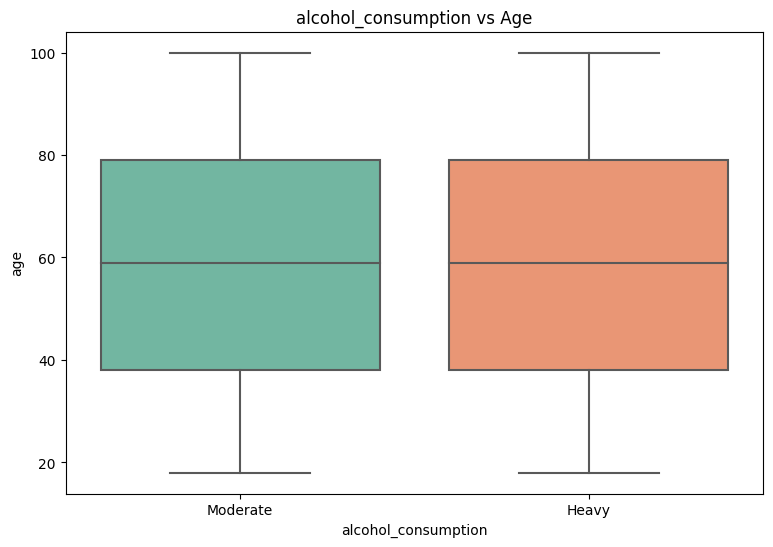

In [10]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="alcohol_consumption", y="age", palette="Set2")
plt.title("alcohol_consumption vs Age")
plt.xlabel("alcohol_consumption")
plt.ylabel("age")
plt.show()

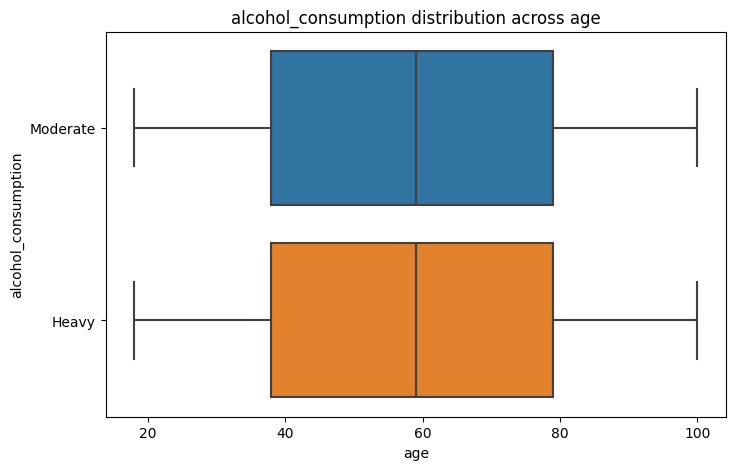

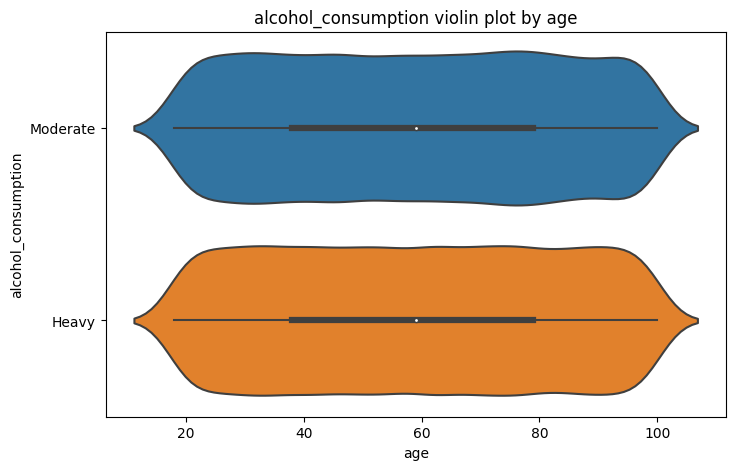

In [11]:
num_col = "alcohol_consumption"       # numerical column
cat_col = "age"   # categorical column

#  Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=cat_col, y=num_col, data=df)
plt.title(f"{num_col} distribution across {cat_col}")
plt.show()

#  Violin plot
plt.figure(figsize=(8,5))
sns.violinplot(x=cat_col, y=num_col, data=df, inner="box")
plt.title(f"{num_col} violin plot by {cat_col}")
plt.show()



In [12]:
def eda_visuals(df, corr_method='spearman'):
    
    # Select numerical and categorical columns
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    # Color palette
    palette = sns.color_palette("husl", len(numerical_cols))

    # --Boxplots (Outliers)--
    plt.figure(figsize=(25, 18))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(6, 6, i)
        sns.boxplot(y=df[col], color=palette[i-1])
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

    # --Distributions--
    plt.figure(figsize=(25, 15))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(6, 6, i)
        sns.histplot(df[col], kde=True, color=palette[i-1], bins=30)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

    # --Pie Charts for categorical data--
    if len(categorical_cols) > 0:
        plt.figure(figsize=(18, 12))
        for i, col in enumerate(categorical_cols, 1):
            plt.subplot(3, 3, i)
            df[col].value_counts().plot.pie(
                autopct='%1.1f%%',
                startangle=90,
                cmap='tab20'
            )
            plt.title(f'Pie Chart of {col}')
            plt.ylabel('')
        plt.tight_layout()
        plt.show()

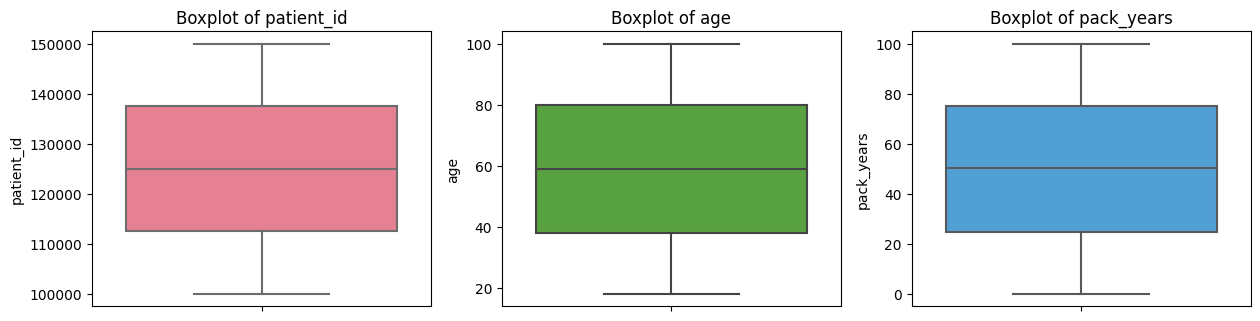

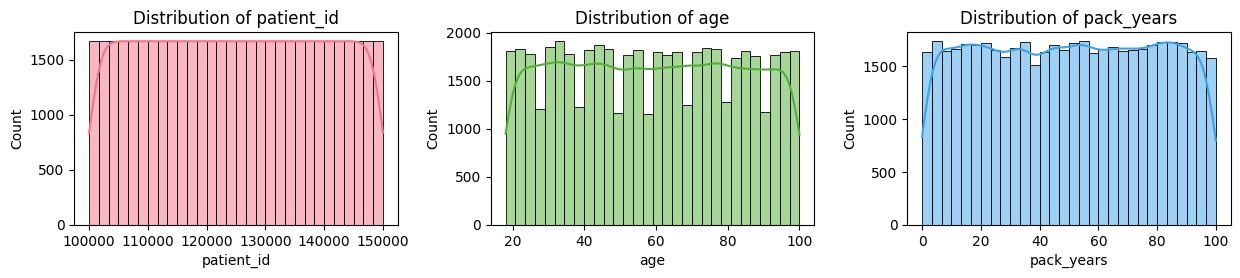

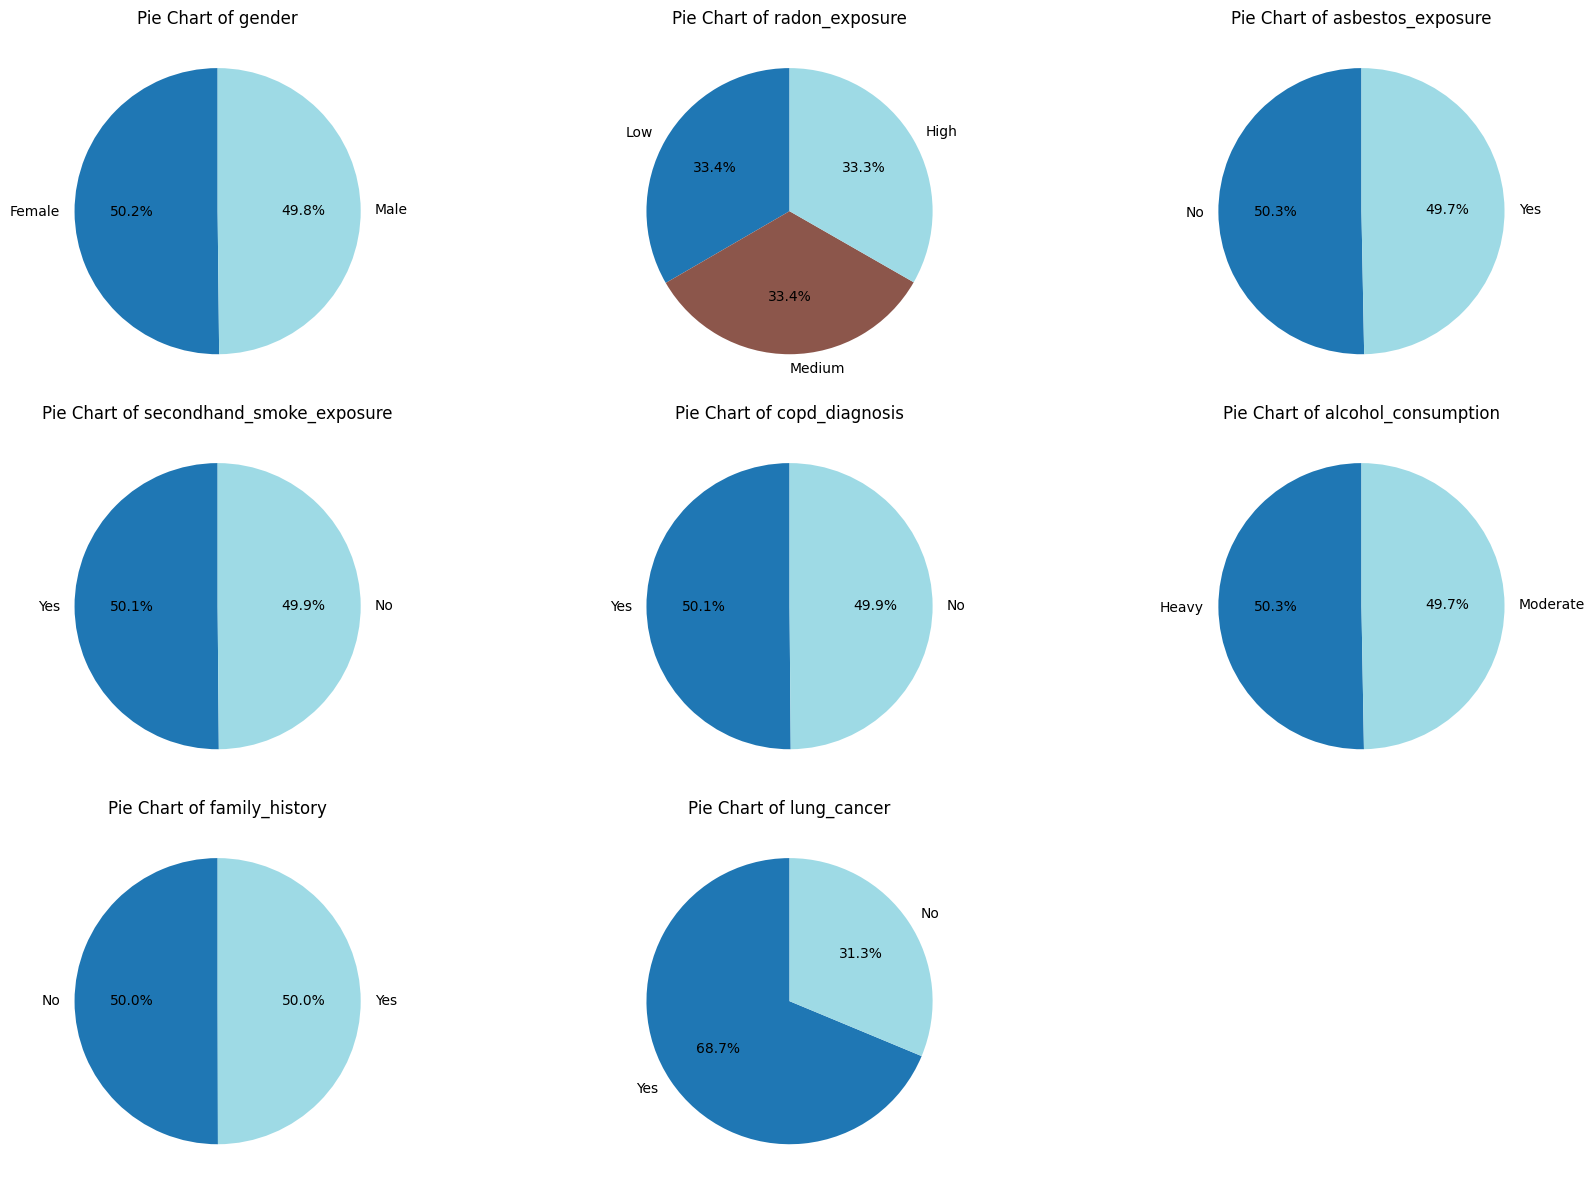

In [13]:
eda_visuals(df)

In [14]:
def eda_relationships(df, target_col="lung_cancer"):
    
    sns.set_theme(
    style="whitegrid",       # "whitegrid" is best for numeric vs categorical
    palette="Set2",          # soft professional colors
    context="talk"           # bigger labels for readability
)


    # Matplotlib tweaks
    plt.rcParams["figure.figsize"] = (6, 4)   # default figure size
    plt.rcParams["axes.titlesize"] = 12       # title font size
    plt.rcParams["axes.labelsize"] = 11       # axis label size
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10
    plt.rcParams["axes.edgecolor"] = "gray"   # subtle axis lines
    plt.rcParams["axes.linewidth"] = 1.2
    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.3          # softer grid

   
    # Select numeric and categorical columns
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("patient_id", errors="ignore")
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.drop(target_col, errors="ignore")

    # --- Correlation Heatmap ---
    plt.figure(figsize=(6, 4))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="mako", center=0, linewidths=.5)
    plt.title("Correlation Heatmap (Numeric Features)", fontsize=14, color="w")
    plt.show()

    # --- Categorical vs Target ---
    for col in categorical_cols:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=col, hue=target_col, palette="viridis")
        plt.title(f"{col} vs {target_col}", fontsize=14, color="w")
        plt.xticks(rotation=30)
        plt.show()

    # --- Numeric vs Target (Boxplots) ---
    for col in numeric_cols:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=df, x=target_col, y=col, palette="plasma")
        plt.title(f"{col} Distribution by {target_col}", fontsize=14, color="w")
        plt.show()

    # --- Pairplot (Relationships) ---
    selected_features = list(numeric_cols) + [target_col]
    sns.pairplot(df[selected_features], hue=target_col, palette="cubehelix", diag_kind="kde")
    plt.suptitle("Pairwise Relationships", y=1.02, color="w", fontsize=14)
    plt.show()

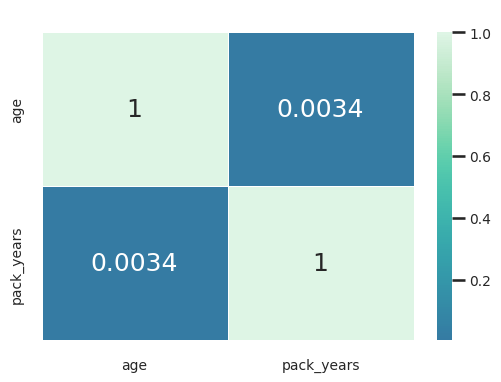

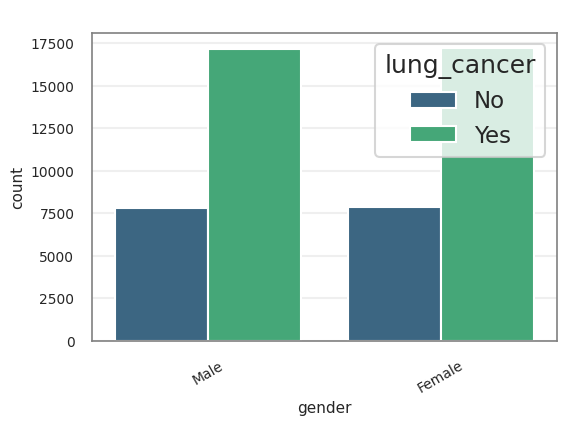

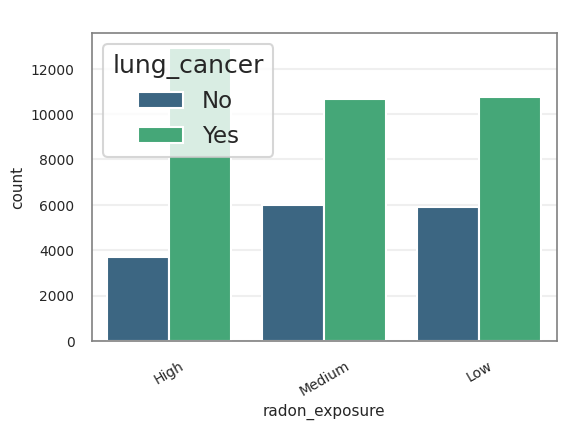

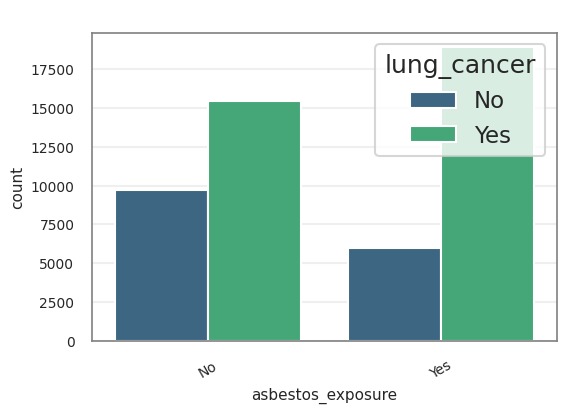

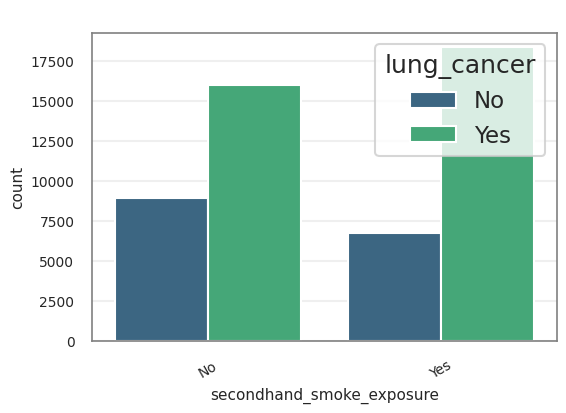

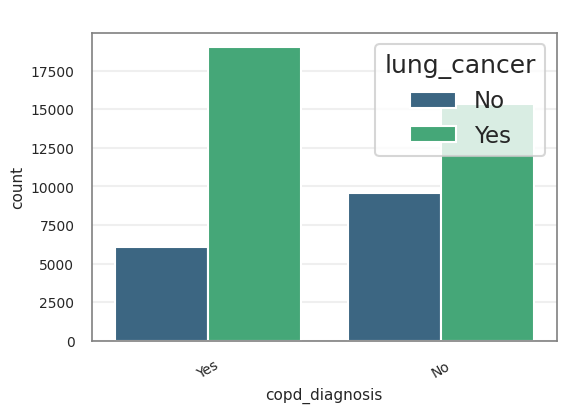

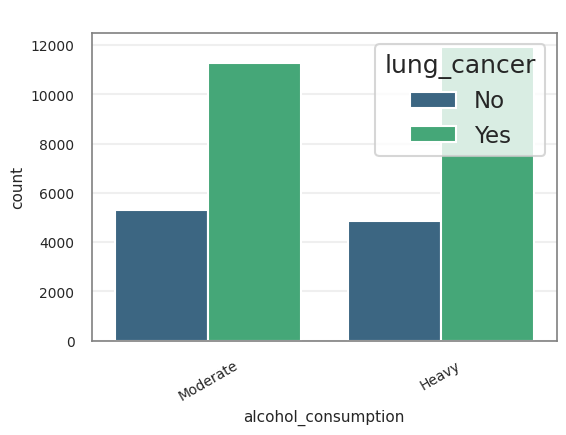

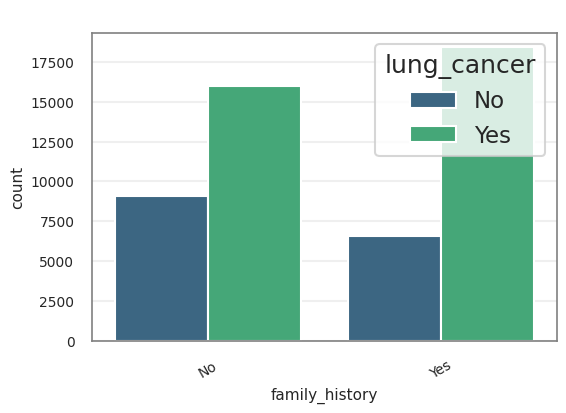

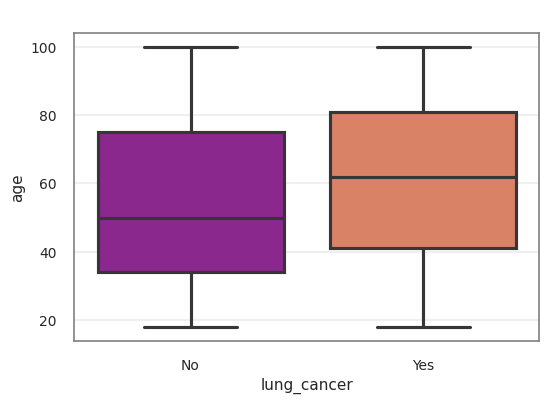

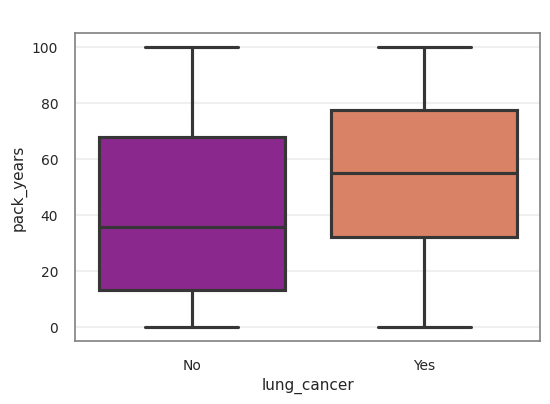

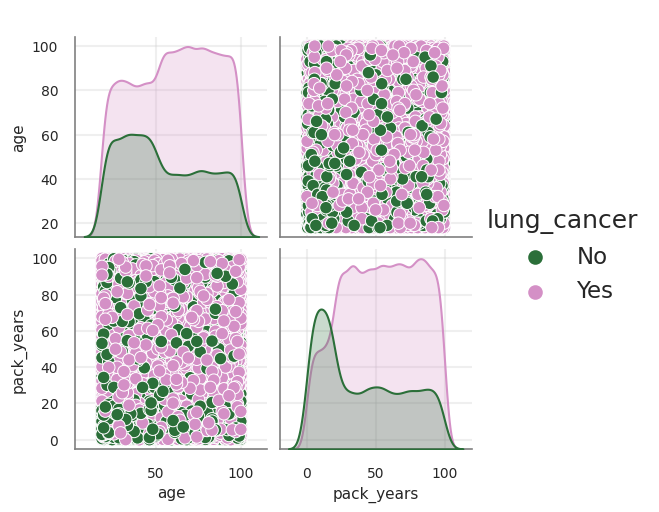

In [15]:
eda_relationships(df, target_col="lung_cancer")

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
import numpy as np

def target_summary(df, target_col, alpha=0.05):
    """
    Summarize how each column relates to the target column.
    Includes numeric and categorical handling + visualizations.
    Performs significance tests (t-test / chi-square).
    Returns a summary DataFrame with p-values.
    """
    
    sns.set_theme(style="whitegrid", palette="Set2", context="talk")
    
    results = []  # store summary for all columns
    
    for col in df.drop(columns=[target_col]).columns:
        print(f"\n{'='*40}\nAnalyzing Column: {col}\n{'='*40}")
        
        if pd.api.types.is_numeric_dtype(df[col]):
            # ---------- Numeric Feature ----------
            stats = df.groupby(target_col)[col].describe()
            print(stats)
            
            test_used, p_val = None, np.nan
            
            # T-test if binary target
            if df[target_col].nunique() == 2:
                groups = [df[df[target_col] == val][col].dropna() for val in df[target_col].unique()]
                if len(groups[0]) > 1 and len(groups[1]) > 1:
                    t_stat, p_val = ttest_ind(groups[0], groups[1])
                    test_used = "t-test"
                    print(f"T-test: t={t_stat:.3f}, p={p_val:.4f}")
            
            # Save results
            results.append({
                "Column": col,
                "Type": "Numeric",
                "Test": test_used,
                "p-value": p_val,
                "Significant": "Yes" if p_val < alpha else "No"
            })
            
            # Plot
            plt.figure(figsize=(7,5))
            sns.boxplot(x=target_col, y=col, data=df, palette="Set2")
            sns.stripplot(x=target_col, y=col, data=df, color="black", alpha=0.4, jitter=True)
            plt.title(f"{col} distribution by {target_col}")
            plt.show()
        
        else:
            # ---------- Categorical Feature ----------
            crosstab = pd.crosstab(df[col], df[target_col], normalize="index") * 100
            print("Percentage distribution by target:\n", crosstab)
            
            # Chi-square test
            contingency = pd.crosstab(df[col], df[target_col])
            chi2, p_val, dof, expected = chi2_contingency(contingency)
            print(f"Chi-square: χ²={chi2:.3f}, p={p_val:.4f}, dof={dof}")
            
            results.append({
                "Column": col,
                "Type": "Categorical",
                "Test": "Chi-square",
                "p-value": p_val,
                "Significant": "Yes" if p_val < alpha else "No"
            })
            
            # Plot
            plt.figure(figsize=(7,5))
            sns.countplot(x=col, hue=target_col, data=df, palette="Set2")
            plt.title(f"{col} vs {target_col}")
            plt.xticks(rotation=30)
            plt.show()
    
    # Final summary DataFrame
    summary_df = pd.DataFrame(results)
    print("\n\n===== SUMMARY TABLE =====")
    print(summary_df)
    
    return summary_df



Analyzing Column: patient_id
               count           mean           std       min        25%  \
lung_cancer                                                              
No           15636.0  124939.330647  14444.027450  100000.0  112529.75   
Yes          34364.0  125026.877721  14429.418289  100001.0  112489.50   

                  50%        75%       max  
lung_cancer                                 
No           124950.0  137393.75  149998.0  
Yes          125026.0  137546.25  149999.0  
T-test: t=-0.629, p=0.5295


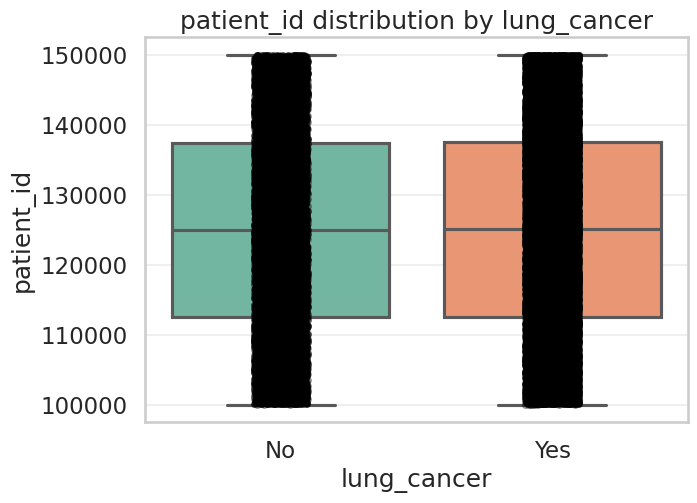


Analyzing Column: age
               count       mean        std   min   25%   50%   75%    max
lung_cancer                                                              
No           15636.0  54.561653  24.113389  18.0  34.0  50.0  75.0  100.0
Yes          34364.0  60.811489  23.630636  18.0  41.0  62.0  81.0  100.0
T-test: t=-27.242, p=0.0000


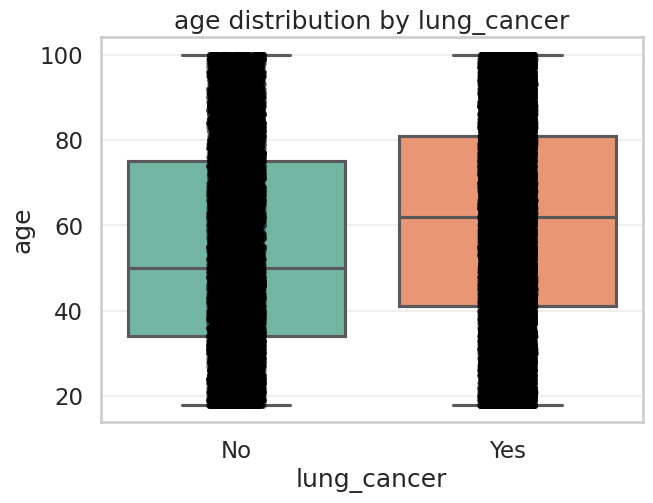


Analyzing Column: gender
Percentage distribution by target:
 lung_cancer         No        Yes
gender                           
Female       31.277656  68.722344
Male         31.266305  68.733695
Chi-square: χ²=0.000, p=0.9859, dof=1


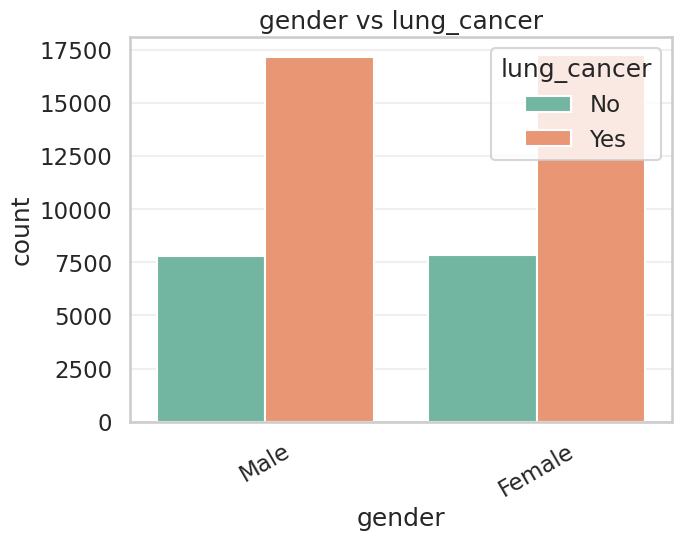


Analyzing Column: pack_years
               count       mean        std       min        25%        50%  \
lung_cancer                                                                  
No           15636.0  40.968390  30.517842  0.002935  13.169439  35.565407   
Yes          34364.0  54.056264  27.090616  0.002753  31.953121  54.832553   

                   75%        max  
lung_cancer                        
No           67.686870  99.985847  
Yes          77.500714  99.999204  
T-test: t=-48.099, p=0.0000


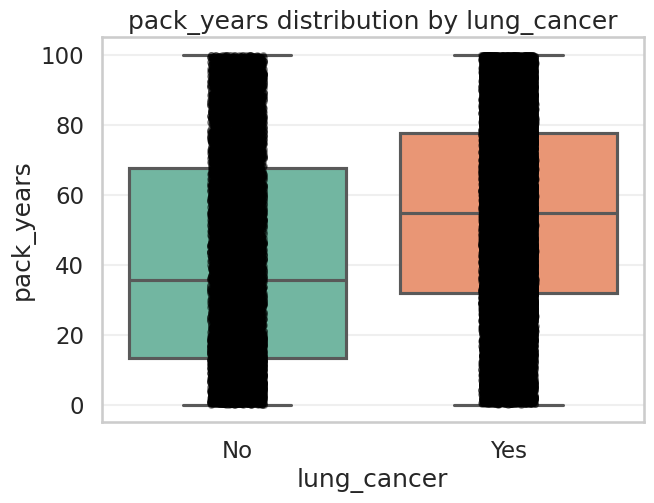


Analyzing Column: radon_exposure
Percentage distribution by target:
 lung_cancer            No        Yes
radon_exposure                      
High            22.315043  77.684957
Low             35.427407  64.572593
Medium          36.051322  63.948678
Chi-square: χ²=932.382, p=0.0000, dof=2


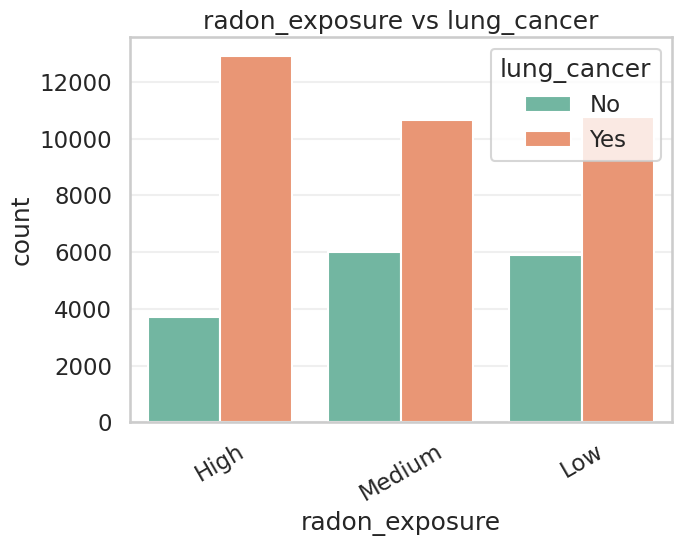


Analyzing Column: asbestos_exposure
Percentage distribution by target:
 lung_cancer               No        Yes
asbestos_exposure                      
No                 38.523319  61.476681
Yes                23.932553  76.067447
Chi-square: χ²=1237.436, p=0.0000, dof=1


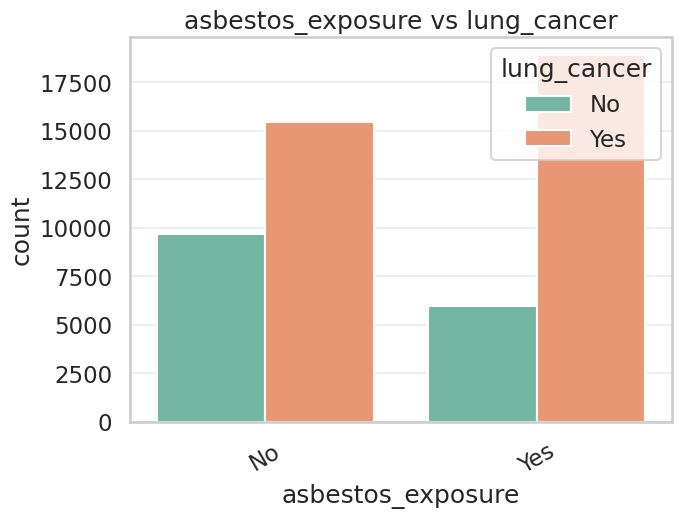


Analyzing Column: secondhand_smoke_exposure
Percentage distribution by target:
 lung_cancer                       No        Yes
secondhand_smoke_exposure                      
No                         35.775879  64.224121
Yes                        26.792197  73.207803
Chi-square: χ²=468.964, p=0.0000, dof=1


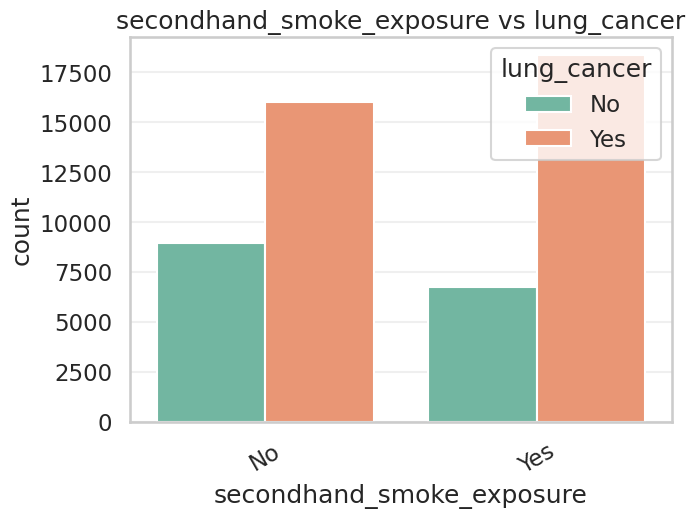


Analyzing Column: copd_diagnosis
Percentage distribution by target:
 lung_cancer            No        Yes
copd_diagnosis                      
No              38.409401  61.590599
Yes             24.172185  75.827815
Chi-square: χ²=1178.213, p=0.0000, dof=1


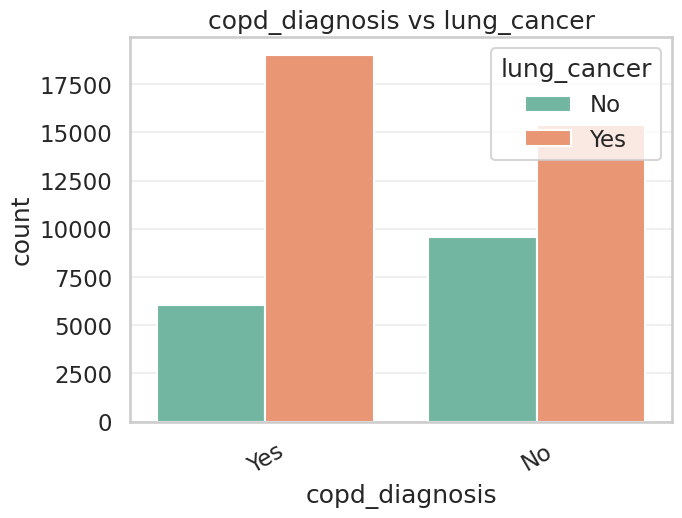


Analyzing Column: alcohol_consumption
Percentage distribution by target:
 lung_cancer                 No        Yes
alcohol_consumption                      
Heavy                28.928529  71.071471
Moderate             32.070463  67.929537
Chi-square: χ²=38.671, p=0.0000, dof=1


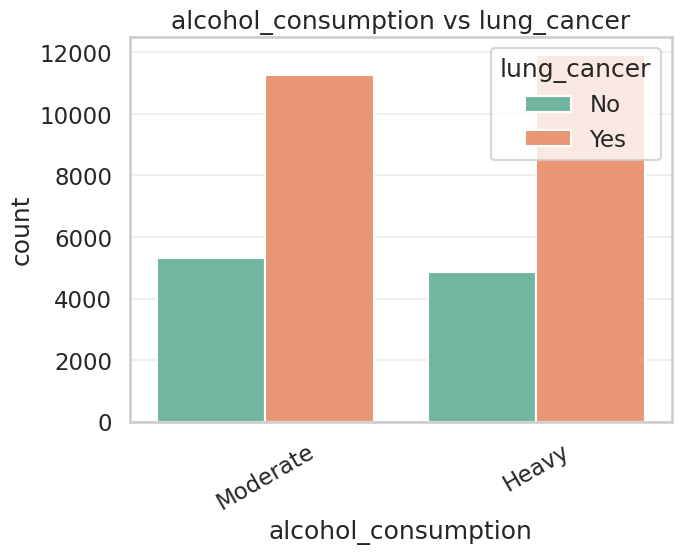


Analyzing Column: family_history
Percentage distribution by target:
 lung_cancer            No        Yes
family_history                      
No              36.223368  63.776632
Yes             26.313893  73.686107
Chi-square: χ²=570.652, p=0.0000, dof=1


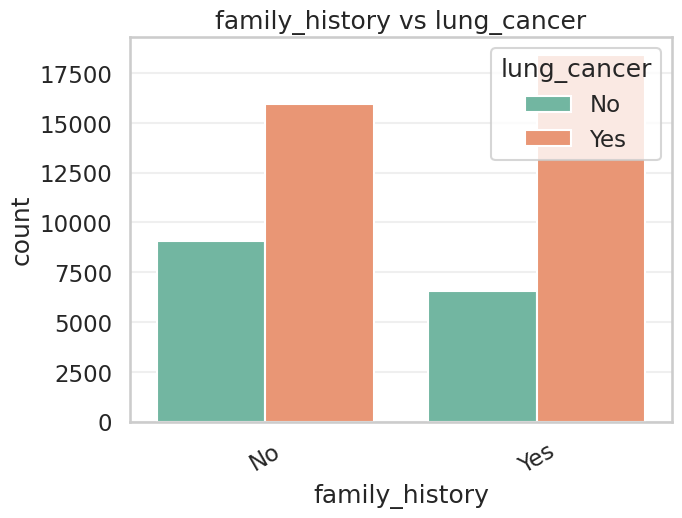



===== SUMMARY TABLE =====
                      Column         Type        Test        p-value  \
0                 patient_id      Numeric      t-test   5.295090e-01   
1                        age      Numeric      t-test  3.188358e-162   
2                     gender  Categorical  Chi-square   9.858570e-01   
3                 pack_years      Numeric      t-test   0.000000e+00   
4             radon_exposure  Categorical  Chi-square  3.433861e-203   
5          asbestos_exposure  Categorical  Chi-square  4.461125e-271   
6  secondhand_smoke_exposure  Categorical  Chi-square  5.385366e-104   
7             copd_diagnosis  Categorical  Chi-square  3.313938e-258   
8        alcohol_consumption  Categorical  Chi-square   5.015101e-10   
9             family_history  Categorical  Chi-square  4.051152e-126   

  Significant  
0          No  
1         Yes  
2          No  
3         Yes  
4         Yes  
5         Yes  
6         Yes  
7         Yes  
8         Yes  
9         Yes  


In [17]:
summary = target_summary(df, "lung_cancer")


In [18]:
# lung_cancer_pipeline_with_dl.py

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RND = 42
sns.set_theme(style="whitegrid", palette="Set2", context="talk")

# ------------------------
# Load
# ------------------------
def load_data(path):
    return pd.read_csv(path) if str(path).endswith(".csv") else pd.read_excel(path)

# ------------------------
# Preprocessing
# ------------------------
def build_preprocessor(X):
    num_cols = X.select_dtypes(include="number").columns.tolist()
    cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ])
    return preprocessor, num_cols, cat_cols

# ------------------------
# Evaluation
# ------------------------
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model,"predict_proba") else None

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_test, y_proba)
        metrics["pr_auc"] = average_precision_score(y_test, y_proba)

    print(f"\n{name} results:")
    for k,v in metrics.items():
        print(f"  {k}: {v:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=3))
    return metrics

# ------------------------
# Deep Learning Model
# ------------------------
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def train_dl_model(X_train, y_train, X_test, y_test):
    model = build_mlp(X_train.shape[1])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20, batch_size=32, verbose=0
    )

    y_proba = model.predict(X_test).ravel()
    y_pred = (y_proba > 0.5).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

    print("\nDeep Learning results:")
    for k,v in metrics.items():
        print(f"  {k}: {v:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=3))

    return model, metrics

# ------------------------
# Main
# ------------------------
def run_pipeline(df, target="lung_cancer"):
    le = LabelEncoder()
    df[target] = le.fit_transform(df[target].astype(str))

    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=RND
    )

    preprocessor, num_cols, cat_cols = build_preprocessor(X)
    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RND),
        "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
        "LightGBM": lgb.LGBMClassifier(random_state=RND),
        "CatBoost": CatBoostClassifier(verbose=0, random_state=RND)
    }

    results = {}
    for name, clf in models.items():
        pipe = Pipeline([("preproc", preprocessor), ("clf", clf)])
        pipe.fit(X_train, y_train)
        results[name] = evaluate_model(name, pipe, X_test, y_test)

    # Deep Learning
    dl_model, dl_metrics = train_dl_model(X_train_proc, y_train, X_test_proc, y_test)
    results["DeepLearning"] = dl_metrics

    print("\n=== Final Comparison ===")
    for k,v in results.items():
        print(f"{k}: {v}")

    return results, dl_model

# ------------------------
if __name__ == "__main__":
    data_path = "/kaggle/input/lung-cancer-risk-dataset/lung_cancer_dataset.csv"  # change to your Kaggle csv
    df = load_data(data_path)
    results, dl_model = run_pipeline(df, "lung_cancer")


2025-09-12 06:39:23.314851: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757659163.543920      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757659163.611869      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered



LogisticRegression results:
  accuracy: 0.6709
  f1: 0.7351
  roc_auc: 0.7438
  pr_auc: 0.8636
Confusion matrix:
 [[2143  984]
 [2307 4566]]
              precision    recall  f1-score   support

           0      0.482     0.685     0.566      3127
           1      0.823     0.664     0.735      6873

    accuracy                          0.671     10000
   macro avg      0.652     0.675     0.650     10000
weighted avg      0.716     0.671     0.682     10000


RandomForest results:
  accuracy: 0.7084
  f1: 0.7994
  roc_auc: 0.7321
  pr_auc: 0.8585
Confusion matrix:
 [[1274 1853]
 [1063 5810]]
              precision    recall  f1-score   support

           0      0.545     0.407     0.466      3127
           1      0.758     0.845     0.799      6873

    accuracy                          0.708     10000
   macro avg      0.652     0.626     0.633     10000
weighted avg      0.692     0.708     0.695     10000


XGBoost results:
  accuracy: 0.7312
  f1: 0.8180
  roc_auc: 0.7545


2025-09-12 06:39:58.504705: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Deep Learning results:
  accuracy: 0.7415
  f1: 0.8301
  roc_auc: 0.7699
  pr_auc: 0.8801
Confusion matrix:
 [[1099 2028]
 [ 557 6316]]
              precision    recall  f1-score   support

           0      0.664     0.351     0.460      3127
           1      0.757     0.919     0.830      6873

    accuracy                          0.742     10000
   macro avg      0.710     0.635     0.645     10000
weighted avg      0.728     0.742     0.714     10000


=== Final Comparison ===
LogisticRegression: {'accuracy': 0.6709, 'f1': 0.7350881429606376, 'roc_auc': 0.743763537385833, 'pr_auc': 0.8635639735613525}
RandomForest: {'accuracy': 0.7084, 'f1': 0.7993946064942212, 'roc_auc': 0.7321380953756889, 'pr_auc': 0.8584654796085548}
XGBoost: {'accuracy': 0.7312, 'f1': 0.8180341186027619, 'roc_auc': 0.7544565570861652, 'pr_auc': 0.8705308871579396}
LightGBM: {'accuracy': 0.7437, 'f1': 0.8286650177150878, 'roc_auc': 0.7739365967718679, 'pr_auc': 0.882

In [19]:
def plot_model_comparison(results):
    """
    Plot bar charts comparing model performance across metrics.
    """
    # Convert dict of dicts → DataFrame
    df_results = pd.DataFrame(results).T.reset_index().rename(columns={"index":"Model"})
    
    # Melt for easy plotting
    df_melt = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
    
    plt.figure(figsize=(10,6))
    sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", palette="Set2")
    plt.title("Model Performance Comparison")
    plt.ylabel("Score")
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    
    return df_results



LogisticRegression results:
  accuracy: 0.6709
  f1: 0.7351
  roc_auc: 0.7438
  pr_auc: 0.8636
Confusion matrix:
 [[2143  984]
 [2307 4566]]
              precision    recall  f1-score   support

           0      0.482     0.685     0.566      3127
           1      0.823     0.664     0.735      6873

    accuracy                          0.671     10000
   macro avg      0.652     0.675     0.650     10000
weighted avg      0.716     0.671     0.682     10000


RandomForest results:
  accuracy: 0.7084
  f1: 0.7994
  roc_auc: 0.7321
  pr_auc: 0.8585
Confusion matrix:
 [[1274 1853]
 [1063 5810]]
              precision    recall  f1-score   support

           0      0.545     0.407     0.466      3127
           1      0.758     0.845     0.799      6873

    accuracy                          0.708     10000
   macro avg      0.652     0.626     0.633     10000
weighted avg      0.692     0.708     0.695     10000


XGBoost results:
  accuracy: 0.7312
  f1: 0.8180
  roc_auc: 0.7545


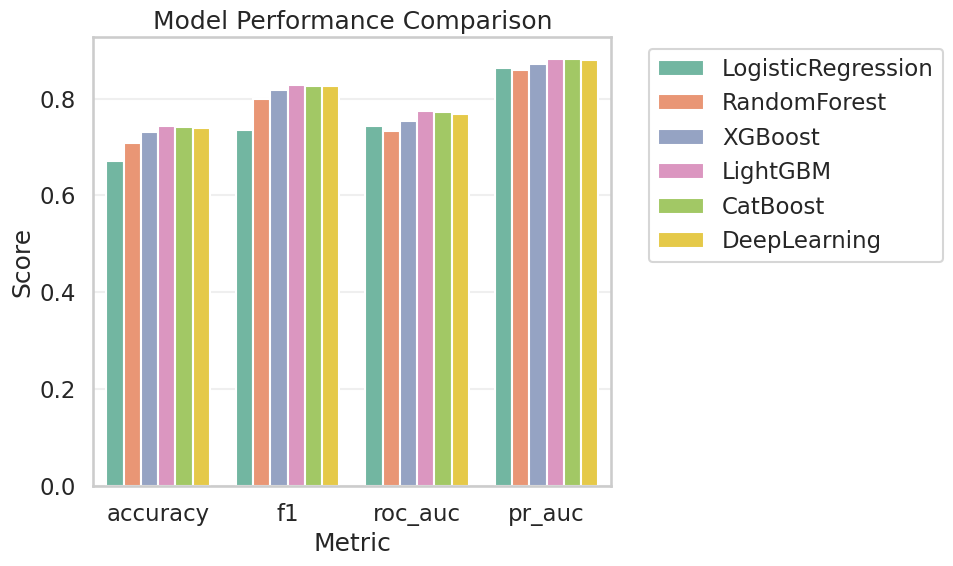

                Model  accuracy        f1   roc_auc    pr_auc
0  LogisticRegression    0.6709  0.735088  0.743764  0.863564
1        RandomForest    0.7084  0.799395  0.732138  0.858465
2             XGBoost    0.7312  0.818034  0.754457  0.870531
3            LightGBM    0.7437  0.828665  0.773937  0.882223
4            CatBoost    0.7404  0.825725  0.771387  0.880982
5        DeepLearning    0.7398  0.825228  0.767213  0.878854


In [20]:
results, dl_model = run_pipeline(df, "lung_cancer")

# Compare visually
df_results = plot_model_comparison(results)
print(df_results)